# PCA Comparison of Two Mongo Scans

This notebook loads two saved scans from MongoDB and compares their layer activations with PCA.

It includes:
- per-scan PCA trajectories
- a shared PCA projection across both scans
- layerwise PCA distances
- scale-aware diagnostics for interpreting whether a distance is large
- original hidden-space cosine and norm deltas per layer

In [23]:
import os
import sys
import tempfile

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from bson.objectid import ObjectId

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)

In [24]:
# Fill these in before running.
APPLICATION_NAME = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

#SCAN_A_ID = "66fc602ade4a4bd5fec2a371" #gt=0
SCAN_A_ID = "66fc6036de4a4bd5fec2a92f" #gt=1
SCAN_B_ID = "66fc602dde4a4bd5fec2a4ac" #gt=0

LAYER_NAME_FILTER = "SelfAttention.o"
LAYER_NAME_FILTER = "DenseReluDense.wo"
TOKEN_SELECTION = "last"   # one of: last, mean
N_SHARED_COMPONENTS = 2
SUBSPACE_COMPONENTS = 3

LABEL_A = "Scan A"
LABEL_B = "Scan B"

In [25]:
backend_cfg = sdk_config.get_backend_config().copy()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def get_mongo_backend(ns_backend):
    backend = ns_backend.backend
    if hasattr(backend, "col"):
        return backend
    if hasattr(backend, "mng"):
        return backend.mng
    raise TypeError("Configured backend does not expose a Mongo collection.")

def load_scan(ns_backend, scan_id):
    mongo_backend = get_mongo_backend(ns_backend)
    doc = mongo_backend.col.find_one({"_id": ObjectId(scan_id)})
    if doc is None:
        raise ValueError(f"No Mongo scan found for _id={scan_id}")
    return ns_backend.deserialize_scan(doc)

scan_a = load_scan(be, SCAN_A_ID)
scan_b = load_scan(be, SCAN_B_ID)

print(f"{LABEL_A}: {scan_a['_id']}")
print(f"{LABEL_B}: {scan_b['_id']}")
print(f"Layer filter: {LAYER_NAME_FILTER}")

Scan A: 66fc6036de4a4bd5fec2a92f
Scan B: 66fc602dde4a4bd5fec2a4ac
Layer filter: DenseReluDense.wo


In [26]:
def vectorize_tensor(tensor, token_selection="last"):
    t = tensor.float().cpu()
    if t.ndim == 1:
        return t.numpy()
    if t.ndim != 2:
        raise ValueError(f"Expected 1D or 2D tensor, got shape {tuple(t.shape)}")
    if token_selection == "last":
        return t[-1].numpy()
    if token_selection == "mean":
        return t.mean(dim=0).numpy()
    raise ValueError(f"Unsupported TOKEN_SELECTION={token_selection}")

def short_layer_label(layer_name, ordinal):
    parts = layer_name.split(".")
    return f"L{ordinal:02d} | {parts[-3]}.{parts[-2]}.{parts[-1]}"

def extract_layer_matrix(scan, layer_name_filter, token_selection="last"):
    rows = []
    labels = []
    full_names = []
    for layer_id in scan["layer_order"]:
        layer_name = scan["layer_id_to_name"][layer_id]
        if layer_name_filter not in layer_name:
            continue
        vec = vectorize_tensor(scan["outputs"][layer_id], token_selection=token_selection)
        rows.append(vec)
        labels.append(short_layer_label(layer_name, len(labels)))
        full_names.append(layer_name)

    if not rows:
        raise ValueError(f"No layers matched filter '{layer_name_filter}'")

    matrix = np.stack(rows, axis=0)
    return {
        "matrix": matrix,
        "labels": labels,
        "full_names": full_names,
    }

def fit_snapshot_pca(snapshot_bundle, n_components=2):
    matrix = snapshot_bundle["matrix"]
    pca = PCA(n_components=n_components)
    projected = pca.fit_transform(matrix)
    return {
        **snapshot_bundle,
        "pca": pca,
        "projected": projected,
        "variance_pct": pca.explained_variance_ratio_ * 100.0,
    }

def plot_snapshot_projection(result, label, color):
    proj = result["projected"]
    labels = result["labels"]
    var = result["variance_pct"]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(proj[:, 0], proj[:, 1], color=color, alpha=0.55, linewidth=1.5)
    ax.scatter(proj[:, 0], proj[:, 1], color=color, s=45)

    for i, txt in enumerate(labels):
        ax.annotate(txt, (proj[i, 0], proj[i, 1]), xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_title(f"{label}: PCA trajectory across matched layers")
    ax.set_xlabel(f"PC1 ({var[0]:.2f}% variance)")
    ax.set_ylabel(f"PC2 ({var[1]:.2f}% variance)")
    plt.tight_layout()
    plt.show()

def principal_angles_deg(components_a, components_b):
    overlap = components_a @ components_b.T
    singular_values = np.linalg.svd(overlap, compute_uv=False)
    singular_values = np.clip(singular_values, -1.0, 1.0)
    return np.degrees(np.arccos(singular_values))

def cosine_similarity_rows(a, b, eps=1e-12):
    numer = np.sum(a * b, axis=1)
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return numer / np.maximum(denom, eps)

def consecutive_step_lengths(points):
    if len(points) < 2:
        return np.array([])
    return np.linalg.norm(np.diff(points, axis=0), axis=1)

bundle_a = extract_layer_matrix(scan_a, LAYER_NAME_FILTER, token_selection=TOKEN_SELECTION)
bundle_b = extract_layer_matrix(scan_b, LAYER_NAME_FILTER, token_selection=TOKEN_SELECTION)

print(f"{LABEL_A}: {bundle_a['matrix'].shape[0]} matched layers x {bundle_a['matrix'].shape[1]} hidden dims")
print(f"{LABEL_B}: {bundle_b['matrix'].shape[0]} matched layers x {bundle_b['matrix'].shape[1]} hidden dims")

if bundle_a["matrix"].shape[1] != bundle_b["matrix"].shape[1]:
    raise ValueError("Scans do not share the same hidden dimension.")

Scan A: 48 matched layers x 1024 hidden dims
Scan B: 48 matched layers x 1024 hidden dims


Scan A explained variance: PC1=95.68%  PC2=3.34%


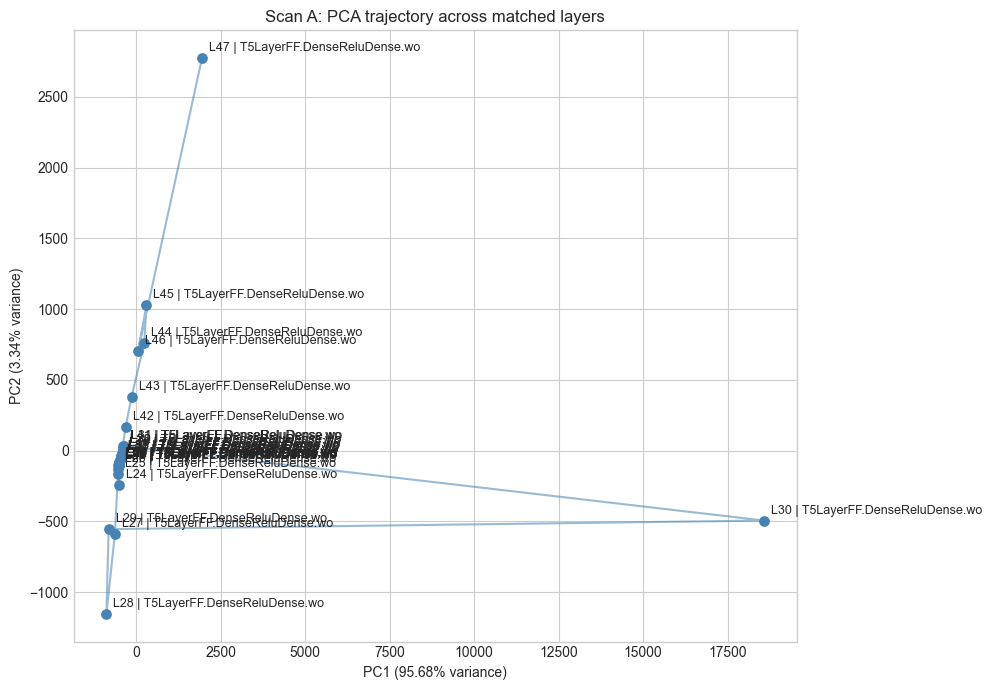

In [27]:
scan_a_pca = fit_snapshot_pca(bundle_a, n_components=2)
print(f"{LABEL_A} explained variance: PC1={scan_a_pca['variance_pct'][0]:.2f}%  PC2={scan_a_pca['variance_pct'][1]:.2f}%")
plot_snapshot_projection(scan_a_pca, LABEL_A, color="steelblue")

Scan B explained variance: PC1=96.67%  PC2=2.44%


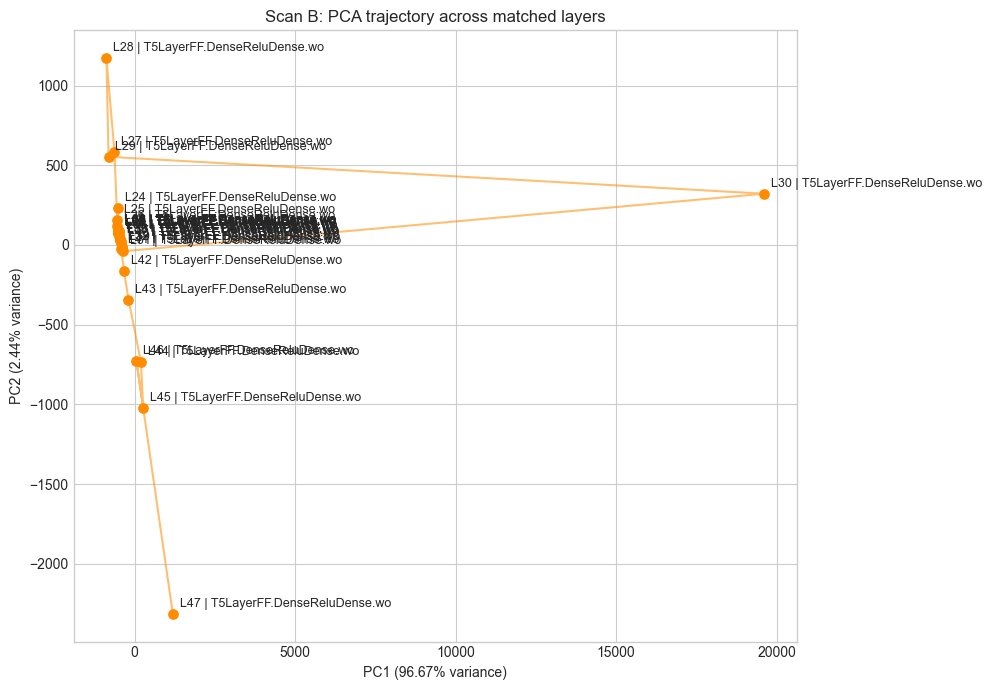

In [28]:
scan_b_pca = fit_snapshot_pca(bundle_b, n_components=2)
print(f"{LABEL_B} explained variance: PC1={scan_b_pca['variance_pct'][0]:.2f}%  PC2={scan_b_pca['variance_pct'][1]:.2f}%")
plot_snapshot_projection(scan_b_pca, LABEL_B, color="darkorange")

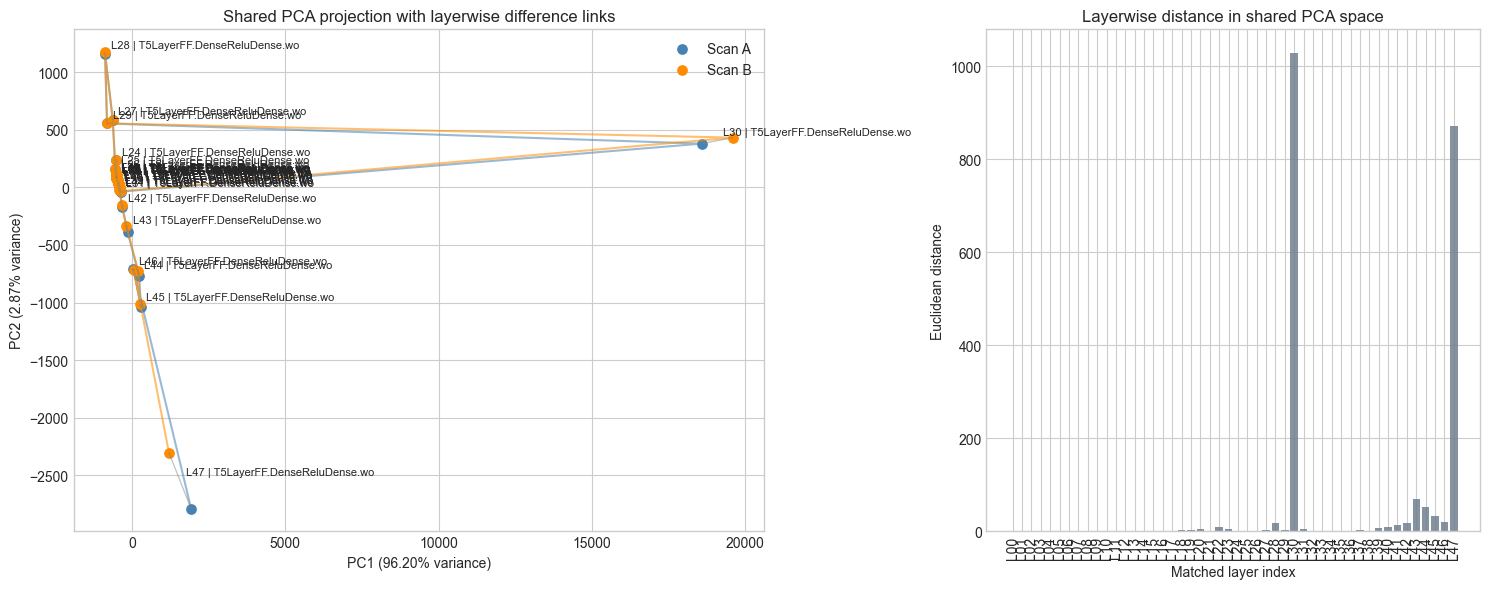

In [29]:
n_common_layers = min(bundle_a["matrix"].shape[0], bundle_b["matrix"].shape[0])
if bundle_a["matrix"].shape[0] != bundle_b["matrix"].shape[0]:
    print(f"Warning: layer counts differ; comparing first {n_common_layers} matched layers only.")

mat_a = bundle_a["matrix"][:n_common_layers]
mat_b = bundle_b["matrix"][:n_common_layers]
labels_common = bundle_a["labels"][:n_common_layers]

shared_pca = PCA(n_components=N_SHARED_COMPONENTS)
shared_pca.fit(np.vstack([mat_a, mat_b]))
proj_a_shared = shared_pca.transform(mat_a)
proj_b_shared = shared_pca.transform(mat_b)
shared_var = shared_pca.explained_variance_ratio_ * 100.0

segments = [np.vstack([proj_a_shared[i], proj_b_shared[i]]) for i in range(n_common_layers)]
pca_distances = np.linalg.norm(proj_a_shared - proj_b_shared, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.4, 1.0]})
ax0, ax1 = axes

ax0.plot(proj_a_shared[:, 0], proj_a_shared[:, 1], color="steelblue", alpha=0.55, linewidth=1.5)
ax0.plot(proj_b_shared[:, 0], proj_b_shared[:, 1], color="darkorange", alpha=0.55, linewidth=1.5)
ax0.scatter(proj_a_shared[:, 0], proj_a_shared[:, 1], color="steelblue", s=45, label=LABEL_A)
ax0.scatter(proj_b_shared[:, 0], proj_b_shared[:, 1], color="darkorange", s=45, label=LABEL_B)
ax0.add_collection(LineCollection(segments, colors="gray", linewidths=1.0, alpha=0.45))

for i, txt in enumerate(labels_common):
    mid_x = 0.5 * (proj_a_shared[i, 0] + proj_b_shared[i, 0])
    mid_y = 0.5 * (proj_a_shared[i, 1] + proj_b_shared[i, 1])
    ax0.annotate(txt, (mid_x, mid_y), xytext=(4, 4), textcoords="offset points", fontsize=8)

ax0.set_title("Shared PCA projection with layerwise difference links")
ax0.set_xlabel(f"PC1 ({shared_var[0]:.2f}% variance)")
ax0.set_ylabel(f"PC2 ({shared_var[1]:.2f}% variance)")
ax0.legend()

ax1.bar(np.arange(n_common_layers), pca_distances, color="slategray", alpha=0.85)
ax1.set_title("Layerwise distance in shared PCA space")
ax1.set_xlabel("Matched layer index")
ax1.set_ylabel("Euclidean distance")
ax1.set_xticks(np.arange(n_common_layers))
ax1.set_xticklabels([f"L{i:02d}" for i in range(n_common_layers)], rotation=90)

plt.tight_layout()
plt.show()

In [30]:
step_a = consecutive_step_lengths(proj_a_shared)
step_b = consecutive_step_lengths(proj_b_shared)
all_shared_points = np.vstack([proj_a_shared, proj_b_shared])
cloud_extent = np.linalg.norm(all_shared_points.max(axis=0) - all_shared_points.min(axis=0))

distance_mean = pca_distances.mean()
distance_std = pca_distances.std(ddof=0)
distance_z = np.zeros_like(pca_distances) if distance_std == 0 else (pca_distances - distance_mean) / distance_std
distance_rank = np.argsort(np.argsort(pca_distances))
distance_percentile = 100.0 * distance_rank / max(len(pca_distances) - 1, 1)

mean_step_a = step_a.mean() if len(step_a) else np.nan
mean_step_b = step_b.mean() if len(step_b) else np.nan
mean_step_both = np.nanmean([mean_step_a, mean_step_b])
distance_over_step = pca_distances / mean_step_both if np.isfinite(mean_step_both) and mean_step_both > 0 else np.full_like(pca_distances, np.nan)
distance_over_cloud = pca_distances / cloud_extent if cloud_extent > 0 else np.full_like(pca_distances, np.nan)

hidden_delta = mat_a - mat_b
hidden_l2 = np.linalg.norm(hidden_delta, axis=1)
hidden_norm_a = np.linalg.norm(mat_a, axis=1)
hidden_norm_b = np.linalg.norm(mat_b, axis=1)
hidden_delta_ratio = hidden_l2 / np.maximum(0.5 * (hidden_norm_a + hidden_norm_b), 1e-12)
hidden_cosine = cosine_similarity_rows(mat_a, mat_b)

layer_summary = {
    "layer": labels_common,
    "pca_distance": pca_distances,
    "pca_distance_z": distance_z,
    "pca_distance_percentile": distance_percentile,
    "distance_over_mean_step": distance_over_step,
    "distance_over_cloud_extent": distance_over_cloud,
    "hidden_cosine": hidden_cosine,
    "hidden_l2": hidden_l2,
    "hidden_delta_ratio": hidden_delta_ratio,
}

top_idx = int(np.argmax(pca_distances))
print("Distance scale diagnostics")
print("-" * 90)
print(f"mean shared-PCA layer distance     : {distance_mean:.6f}")
print(f"std shared-PCA layer distance      : {distance_std:.6f}")
print(f"max shared-PCA layer distance      : {pca_distances[top_idx]:.6f}")
print(f"max-distance layer                 : {labels_common[top_idx]}")
print(f"max-distance z-score               : {distance_z[top_idx]:.6f}")
print(f"max-distance percentile            : {distance_percentile[top_idx]:.2f}")
print(f"mean within-scan PCA step (A)      : {mean_step_a:.6f}")
print(f"mean within-scan PCA step (B)      : {mean_step_b:.6f}")
print(f"shared PCA cloud extent            : {cloud_extent:.6f}")
print(f"max distance / mean step           : {distance_over_step[top_idx]:.6f}")
print(f"max distance / cloud extent        : {distance_over_cloud[top_idx]:.6f}")
print(f"hidden cosine at max-distance layer: {hidden_cosine[top_idx]:.6f}")
print(f"hidden delta ratio at max layer    : {hidden_delta_ratio[top_idx]:.6f}")

print("\nTop 10 layers by shared-PCA distance")
order = np.argsort(-pca_distances)
for rank, idx in enumerate(order[:10], start=1):
    print(
        f"{rank:>2}. {labels_common[idx]:<28} "
        f"dist={pca_distances[idx]:9.4f}  "
        f"z={distance_z[idx]:7.3f}  "
        f"pct={distance_percentile[idx]:6.2f}  "
        f"stepx={distance_over_step[idx]:7.3f}  "
        f"cloudx={distance_over_cloud[idx]:7.3f}  "
        f"cos={hidden_cosine[idx]:8.4f}  "
        f"delta_ratio={hidden_delta_ratio[idx]:8.4f}"
    )

Distance scale diagnostics
------------------------------------------------------------------------------------------
mean shared-PCA layer distance     : 45.952374
std shared-PCA layer distance      : 189.702393
max shared-PCA layer distance      : 1028.146118
max-distance layer                 : L30 | T5LayerFF.DenseReluDense.wo
max-distance z-score               : 5.177550
max-distance percentile            : 100.00
mean within-scan PCA step (A)      : 966.082886
mean within-scan PCA step (B)      : 990.225891
shared PCA cloud extent            : 20864.976562
max distance / mean step           : 1.051108
max distance / cloud extent        : 0.049276
hidden cosine at max-distance layer: 0.999998
hidden delta ratio at max layer    : 0.052473

Top 10 layers by shared-PCA distance
 1. L30 | T5LayerFF.DenseReluDense.wo dist=1028.1461  z=  5.178  pct=100.00  stepx=  1.051  cloudx=  0.049  cos=  1.0000  delta_ratio=  0.0525
 2. L47 | T5LayerFF.DenseReluDense.wo dist= 872.3146  z=  4.356  p

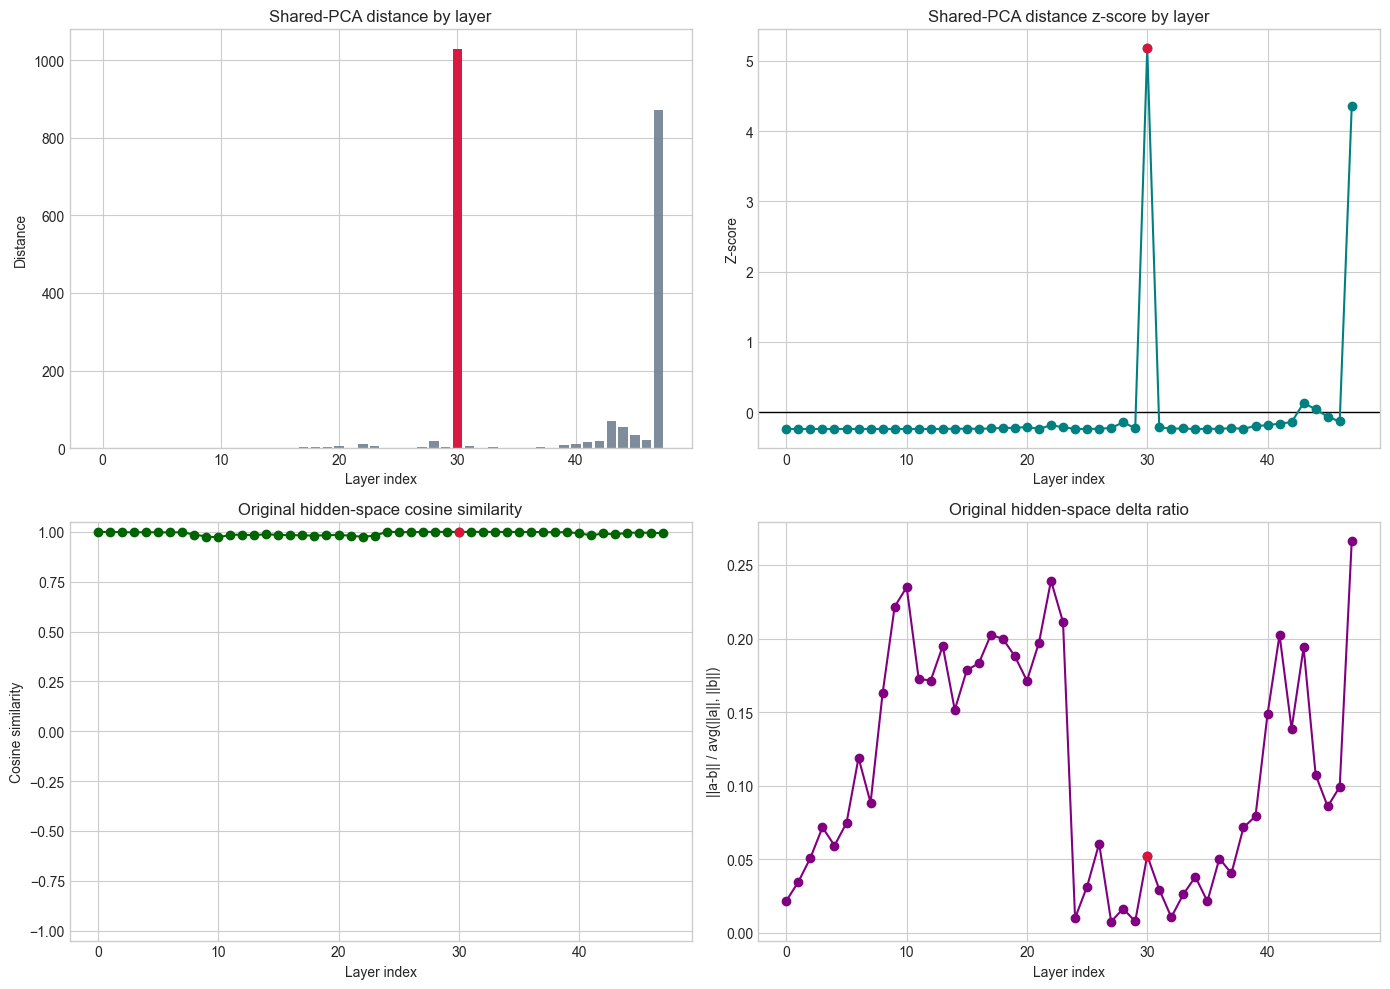

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.ravel()

x = np.arange(n_common_layers)
highlight = np.argmax(pca_distances)

ax1.bar(x, pca_distances, color="slategray", alpha=0.9)
ax1.bar(highlight, pca_distances[highlight], color="crimson", alpha=0.95)
ax1.set_title("Shared-PCA distance by layer")
ax1.set_xlabel("Layer index")
ax1.set_ylabel("Distance")

ax2.axhline(0.0, color="black", linewidth=1)
ax2.plot(x, distance_z, marker="o", color="teal")
ax2.scatter([highlight], [distance_z[highlight]], color="crimson", zorder=3)
ax2.set_title("Shared-PCA distance z-score by layer")
ax2.set_xlabel("Layer index")
ax2.set_ylabel("Z-score")

ax3.plot(x, hidden_cosine, marker="o", color="darkgreen")
ax3.scatter([highlight], [hidden_cosine[highlight]], color="crimson", zorder=3)
ax3.set_ylim(-1.05, 1.05)
ax3.set_title("Original hidden-space cosine similarity")
ax3.set_xlabel("Layer index")
ax3.set_ylabel("Cosine similarity")

ax4.plot(x, hidden_delta_ratio, marker="o", color="purple")
ax4.scatter([highlight], [hidden_delta_ratio[highlight]], color="crimson", zorder=3)
ax4.set_title("Original hidden-space delta ratio")
ax4.set_xlabel("Layer index")
ax4.set_ylabel("||a-b|| / avg(||a||, ||b||)")

plt.tight_layout()
plt.show()

In [32]:
k = min(SUBSPACE_COMPONENTS, n_common_layers, mat_a.shape[1])
pca_a_k = PCA(n_components=k).fit(mat_a)
pca_b_k = PCA(n_components=k).fit(mat_b)

component_cosines = np.abs(np.sum(pca_a_k.components_ * pca_b_k.components_, axis=1))
angles_deg = principal_angles_deg(pca_a_k.components_, pca_b_k.components_)

metrics = {
    "mean_layer_distance_shared_pca": float(pca_distances.mean()),
    "max_layer_distance_shared_pca": float(pca_distances.max()),
    "frobenius_distance_shared_pca": float(np.linalg.norm(proj_a_shared - proj_b_shared, ord="fro")),
    "pc1_path_correlation_shared": float(np.corrcoef(proj_a_shared[:, 0], proj_b_shared[:, 0])[0, 1]),
    "pc2_path_correlation_shared": float(np.corrcoef(proj_a_shared[:, 1], proj_b_shared[:, 1])[0, 1]),
    "mean_component_loading_cosine": float(component_cosines.mean()),
    "mean_principal_angle_deg": float(angles_deg.mean()),
    "max_distance_zscore": float(distance_z[top_idx]),
    "max_distance_over_mean_step": float(distance_over_step[top_idx]),
    "max_distance_over_cloud_extent": float(distance_over_cloud[top_idx]),
    "min_hidden_cosine": float(hidden_cosine.min()),
    "max_hidden_delta_ratio": float(hidden_delta_ratio.max()),
}

print("Difference metrics")
print("-" * 90)
for key, value in metrics.items():
    print(f"{key:<36} {value:.6f}")

print("\nPer-component loading cosine similarity (sign-invariant)")
for i, value in enumerate(component_cosines, start=1):
    print(f"PC{i}: {value:.6f}")

print("\nPrincipal angles between PCA subspaces")
for i, value in enumerate(angles_deg, start=1):
    print(f"angle_{i}_deg: {value:.6f}")

Difference metrics
------------------------------------------------------------------------------------------
mean_layer_distance_shared_pca       45.952374
max_layer_distance_shared_pca        1028.146118
frobenius_distance_shared_pca        1352.306885
pc1_path_correlation_shared          0.999101
pc2_path_correlation_shared          0.995935
mean_component_loading_cosine        0.983781
mean_principal_angle_deg             6.958457
max_distance_zscore                  5.177550
max_distance_over_mean_step          1.051108
max_distance_over_cloud_extent       0.049276
min_hidden_cosine                    0.972553
max_hidden_delta_ratio               0.266335

Per-component loading cosine similarity (sign-invariant)
PC1: 0.999935
PC2: 0.998426
PC3: 0.952982

Principal angles between PCA subspaces
angle_1_deg: 0.083929
angle_2_deg: 3.151880
angle_3_deg: 17.639563


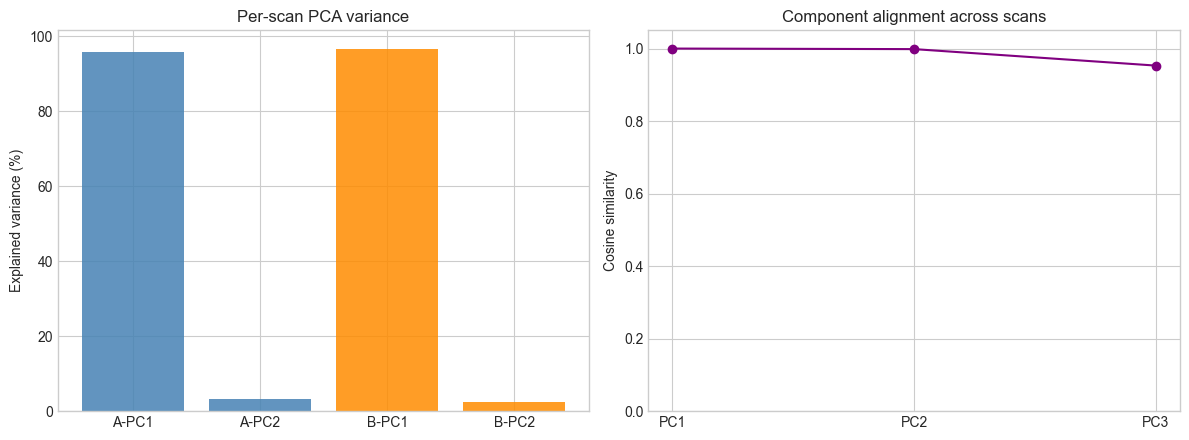

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(["A-PC1", "A-PC2", "B-PC1", "B-PC2"], [
    scan_a_pca["variance_pct"][0],
    scan_a_pca["variance_pct"][1],
    scan_b_pca["variance_pct"][0],
    scan_b_pca["variance_pct"][1],
], color=["steelblue", "steelblue", "darkorange", "darkorange"], alpha=0.85)
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Per-scan PCA variance")

axes[1].plot(component_cosines, marker="o", color="purple")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xticks(np.arange(len(component_cosines)))
axes[1].set_xticklabels([f"PC{i}" for i in range(1, len(component_cosines) + 1)])
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Component alignment across scans")

plt.tight_layout()
plt.show()